# Designação de Áreas de Atendimento dos Padrões de Qualidade do Ar (PQAr)

**Laboratório de Controle da Qualidade do Ar (LCQAr)**

Universidade Federal de Santa Catarina (UFSC)

## Introdução

Este notebook apresenta uma metodologia desenvolvida para realizar a designação de áreas de atendimento dos Padrões de Qualidade do Ar (PQAr) a partir de estações de monitoramento da qualidade do ar.

Este código realiza inicialmente a análise para cada estação de monitoramento. Posteriormente, os resultados individuais das estações podem ser utilizados para determinar a classificação de diferentes áreas de interesse, como municípios ou bacias hidrográficas.

Essa abordagem permite avaliar como diferentes estações localizadas em uma mesma área podem influenciar a classificação dos Padrões de Qualidade do Ar, possibilitando ao usuário comparar os resultados e escolher o critério mais adequado para representar a área analisada.

## Objetivos

Este notebook tem como objetivos:

- calcular o valor de designação para cada estação de monitoramento da qualidade do ar;
- classificar cada estação conforme os Padrões de Qualidade do Ar estabelecidos pela Resolução CONAMA nº 506/2024;
- permitir a determinação da classificação de diferentes áreas (municípios ou bacias hidrográficas) utilizando os resultados das estações localizadas em seu interior;
- disponibilizar ferramentas de visualização espacial por meio de mapas interativos;
- apresentar uma metodologia reproduzível e amplamente documentada para apoiar estudos de qualidade do ar.

## Metodologia Geral

A metodologia implementada neste notebook é composta pelas seguintes etapas:

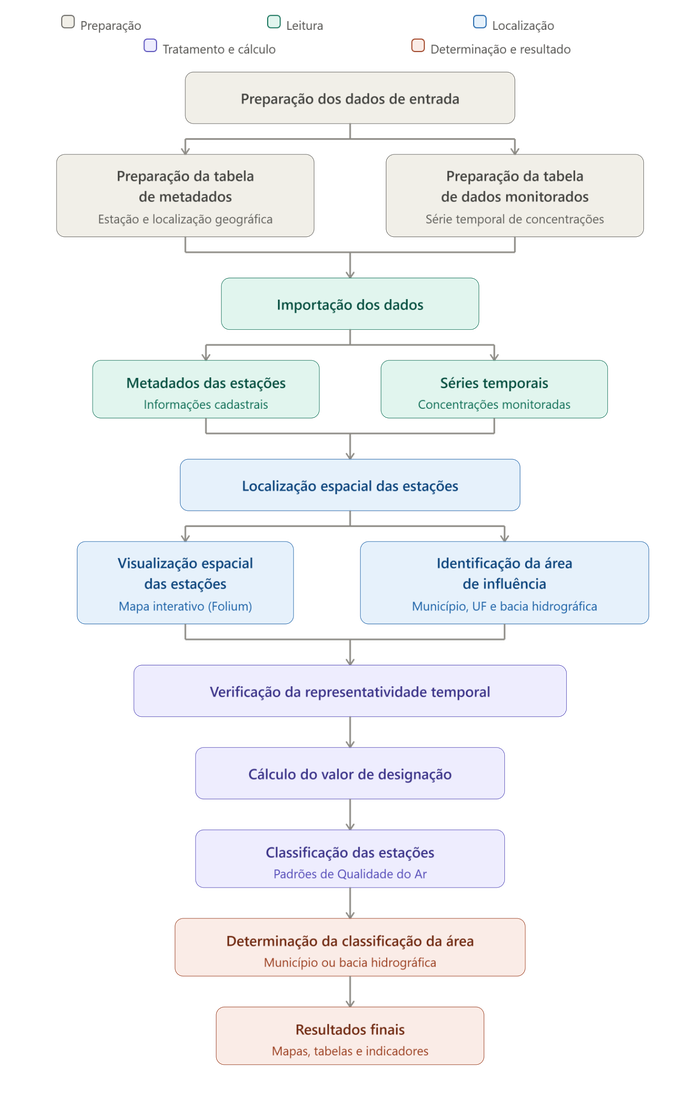

# Preparação dos dados de entrada

Antes de executar este notebook, é necessário preparar dois arquivos de entrada:

- **1 - Tabela de metadados das estações de monitoramento**;
- **2 - Tabela de dados monitorados**.

Esses arquivos serão utilizados em todas as etapas da metodologia, desde a localização espacial das estações até o cálculo do valor de designação e a determinação da classificação da área.

## 1 Tabela de metadados

A tabela de metadados reúne as informações cadastrais das estações de monitoramento que serão analisadas. Ela é utilizada para identificar cada estação, localizar espacialmente os pontos de monitoramento e associá-los às áreas de interesse (municípios ou bacias hidrográficas).

Cada linha da tabela representa uma estação monitorando um determinado poluente.

### 1.1 Estrutura da tabela

A tabela de metadados deve conter as seguintes colunas:

| Coluna | Descrição |
|---------|-----------|
| ID | Identificador único da estação de monitoramento. Deve corresponder ao nome do arquivo de dados monitorados. |
| POLUENTE | Poluente monitorado pela estação (CO, NO₂, SO₂, MP10, MP2.5 ou O₃). |
| LATITUDE | Latitude da estação em graus decimais (SIRGAS 2000). |
| LONGITUDE | Longitude da estação em graus decimais (SIRGAS 2000). |

### 1.2 Elaboração das colunas de metadados

**Para preenchimento da coluna "ID"**, é necessário seguir as instruções da figura a seguir nomeada "Exemplo de ID usado para nomear as estações de monitoramento no banco de dados de qualidade do ar"

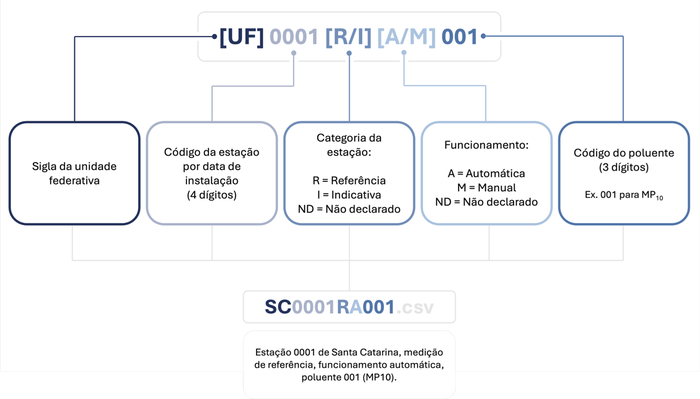

A padronização oficial utiliza as seguintes codificações para os principais poluentes, de acordo com o Ministério do Meio Ambiente e Mudança do Clima (MMA):

- 001: Material Particulado Inalável (MP10)
- 002: Material Particulado Fino (MP2,5)
- 003: Dióxido de Enxofre (SO₂)
- 004: Dióxido de Nitrogênio (NO₂)
- 005: Ozônio (O₃)
- 007: Monóxido de Carbono (CO)

**Para preenchimento da coluna "POLUENTE"** deve ser preenchida com a sigla do poluente monitorado, utilizando letras maiúsculas e exatamente um dos seguintes valores:

- CO
- NO2
- O3
- SO2
- MP10
- MP25

Observação: para o material particulado fino (MP2,5), deve ser utilizado o valor MP25, sem ponto ou vírgula, pois este é o padrão adotado neste notebook.

**Para preenchimento das colunas "LATITUDE" e "LONGITUDE"**, as coordenadas geográficas devem ser informadas em graus decimais, utilizando o sistema de referência SIRGAS 2000 (EPSG:4674).

LATITUDE: valores negativos para o Hemisfério Sul.
LONGITUDE: valores negativos para localidades a oeste do Meridiano de Greenwich.

**Exemplo de preenchimento da tabela de metadados**

| ID | POLUENTE | LATITUDE | LONGITUDE |
|:-------------|:---------:|----------:|-----------:|
| SC0001RA001 | MP10 | -27.59690 | -48.54950 |
| SC0001RA002 | MP25 | -27.59690 | -48.54950 |
| SC0001RA005 | O3 | -27.59690 | -48.54950 |
| SP0002IA004 | NO2 | -23.55052 | -46.63331 |
| SP0002IA003 | SO2 | -23.55052 | -46.63331 |
| SP0002IA006 | CO | -23.55052 | -46.63331 |

No exemplo apresentado, a estação *SC0001RA* monitora os poluentes *MP10*, *MP2,5* e *O₃*, enquanto a estação *SP0002IA* monitora *NO₂*, *SO₂* e *CO*. Embora as coordenadas geográficas e as características da estação permaneçam as mesmas, o *ID* é diferente para cada poluente, pois os *três últimos dígitos* representam o código do poluente monitorado.

### Observação 

Após o preenchimento da tabela de metadados, salve o arquivo no formato *CSV (.csv)* utilizando o seguinte nome:

**estacoes.csv**

Este será o único arquivo de metadados utilizado pelo notebook. Durante a execução, o arquivo será importado automaticamente, sendo necessário manter exatamente esse nome.

## 2 Tabela de dados monitorados

A tabela de dados monitorados contém a série temporal de concentrações observadas em uma estação de monitoramento para um determinado poluente.

Cada arquivo deve corresponder a **uma única estação monitorando um único poluente**, sendo identificado pelo **ID da estação**, conforme definido na tabela de metadados.

Esses dados serão utilizados para verificar a representatividade temporal da série, calcular o valor de designação da estação e determinar a classificação dos Padrões de Qualidade do Ar (PQAr).

### 2.1 Estrutura da tabela de dados monitorados

A estrutura mínima esperada pelo notebook é apresentada na Tabela a seguir:

| Coluna | Descrição |
|---------|-----------|
| DATETIME | Data e horário da medição. |
| VALOR | Concentração do poluente monitorado. |
| UNIDADE | Unidade da concentração (µg/m³ ou ppm). |

As demais colunas presentes no arquivo (por exemplo, **ANO**, **MES**, **DIA**, **HORA** e **VALOR_ORIGINAL**) podem ser mantidas, porém não são obrigatórias para a execução deste notebook.

**Exemplo de tabela de dados monitorados**

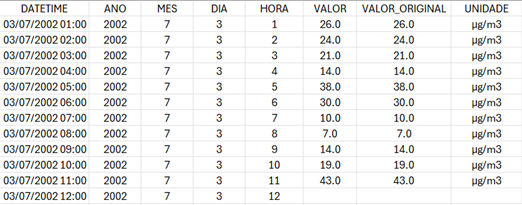

### Observações

1. Os nomes das colunas devem ser escritos **exatamente** conforme especificado neste guia, respeitando letras maiúsculas, minúsculas, acentuação e caracteres especiais.

2. A coluna **DATETIME** deve estar no formato:

   **AAAA-MM-DD HH:MM:SS**

   Exemplo:

   ```
   1998-01-01 01:00:00
   ```

   Não utilize outros formatos de data ou horário.

3. Os valores da coluna **VALOR** devem ser numéricos e utilizar **ponto (.)** como separador decimal.

   **Correto:**

   ```
   15.8
   0.95
   42.0
   ```

   **Incorreto:**

   ```
   15,8
   0,95
   ```

4. A coluna **UNIDADE** deve ser preenchida utilizando exatamente uma das unidades abaixo:

   - µg/m³
   - ppm
   - ppb


5. O arquivo deve conter dados referentes a *uma única estação* e *um único poluente*.

6. O nome do arquivo deve ser exatamente igual ao **ID** informado na tabela de metadados, seguido da extensão **.csv**.

   Exemplo:


   SC0001RA001.csv
 
   

7. O arquivo deve ser salvo no formato *CSV (.csv)*.

8. Recomenda-se que os registros estejam organizados em ordem cronológica crescente para facilitar a verificação dos dados e a interpretação dos resultados.

# Importação dos dados

1. Importação das bibliotecas

Nesta seção são importadas as bibliotecas necessárias para a execução do notebook. Cada biblioteca desempenha uma função específica, desde a manipulação de tabelas e séries temporais até a localização espacial das estações de monitoramento e a geração de mapas interativos.

In [81]:
# IMPORTAÇÃO DAS BIBLIOTECAS

# Manipulação de arquivos e diretórios
import os
from pathlib import Path

# Manipulação de tabelas
import pandas as pd
import numpy as np

# Manipulação de datas
from datetime import datetime

# Widgets interativos
import ipywidgets as widgets
from IPython.display import display, Markdown

# Mapas interativos
import folium

# Manipulação espacial
import geopandas as gpd
from shapely.geometry import Point

# Seleção de arquivos
from tkinter import Tk, filedialog

# Avisos
import warnings
warnings.filterwarnings("ignore")

# CONFIGURAÇÕES

# Mostrar todas as colunas das tabelas
pd.set_option("display.max_columns", None)

# Mostrar maior largura de texto
pd.set_option("display.max_colwidth", None)

# Exibir até 100 linhas
pd.set_option("display.max_rows", 100)

2. Caminho: nesta etapa, informe o caminho da pasta onde estão armazenados os arquivos de entrada do notebook.

Essa pasta deve conter:

- o arquivo **estacoes.csv**;
- os arquivos de dados monitorados das estações (*.csv*).

### Como obter o caminho da pasta

1. Abra a pasta onde estão armazenados os arquivos.
2. Clique na barra de endereço do Explorador de Arquivos.
3. Copie o caminho completo da pasta.
4. Cole o caminho na variável **PASTA_DADOS** da célula abaixo.

Exemplo de caminho: 

```text
C:\Users\diasc\OneDrive\Desktop\Laboratório\AreasAtendimento_PQAr_code
```

In [82]:
# PASTA DE TRABALHO

from pathlib import Path

# INFORME O CAMINHO DA PASTA ONDE ESTÃO OS ARQUIVOS DENTRO DAS ASPAS:  Path(r"..."):
PASTA_DADOS = Path(r"C:\Users\diasc\OneDrive\Desktop\Laboratório\AreasAtendimento_PQAr_code") # ALTERE APENAS ESTA LINHA

# VERIFICAÇÃO DA PASTA

if PASTA_DADOS.exists():
    print("✅ Pasta encontrada com sucesso!")
else:
    raise FileNotFoundError("❌ A pasta informada não foi encontrada. Verifique o caminho informado.")

✅ Pasta encontrada com sucesso!


3. Leitura: nesta etapa, o notebook realiza a leitura da tabela **estacoes.csv**, responsável por armazenar os metadados das estações de monitoramento.

Inicialmente, será verificada a existência do arquivo na pasta informada. Em seguida, a tabela será importada e apresentada ao usuário para conferência das informações.

Caso o arquivo não seja encontrado, a execução do notebook será interrompida até que a inconsistência seja corrigida.

In [83]:
# IMPORTAÇÃO DA TABELA DE METADADOS

arquivo_metadados = PASTA_DADOS / "estacoes.csv"

if not arquivo_metadados.exists():
    raise FileNotFoundError("❌ O arquivo 'estacoes.csv' não foi encontrado na pasta informada.")

metadados = pd.read_csv(arquivo_metadados)

print("✅ Arquivo estacoes.csv encontrado com sucesso!")
print(f"\nNúmero de estações (linhas) encontradas: {len(metadados)}")

display(metadados.head())

✅ Arquivo estacoes.csv encontrado com sucesso!

Número de estações (linhas) encontradas: 2


,ID,POLUENTE,LATITUDE,LONGITUDE
0,SP0091RA007,CO,-23.553540,-46.67270
1,SP0101RA001,MP10,-23.656994,-46.53091


4. Leitura: nesta etapa, o notebook realiza a leitura automática dos arquivos de dados monitorados presentes na pasta de trabalho.

Inicialmente, será verificado se existe um arquivo correspondente para cada **ID** informado na tabela de metadados. Em seguida, os arquivos serão importados e armazenados em memória para utilização nas etapas posteriores.

Caso algum arquivo não seja encontrado ou apresente nomenclatura incompatível com o identificador da estação, o notebook emitirá uma mensagem de aviso indicando a inconsistência.

In [84]:
# LOCALIZAÇÃO DOS ARQUIVOS DE DADOS MONITORADOS

dados_estacoes = {}
arquivos_faltando = []

for _, linha in metadados.iterrows():

    id_estacao = linha["ID"]
    arquivo = PASTA_DADOS / f"{id_estacao}.csv"

    if arquivo.exists():

        dados_estacoes[id_estacao] = pd.read_csv(arquivo)

    else:

        arquivos_faltando.append(id_estacao)

# ARQUIVOS IMPORTADOS

print("="*60)
print("ARQUIVOS IMPORTADOS")
print("="*60)

for id_estacao in dados_estacoes:

    print(f"• {id_estacao}.csv")


# VISUALIZAÇÃO DOS DADOS

for id_estacao, df in dados_estacoes.items():
    
    print(" " * 80)
    print("=" * 80)
    print(f"ESTAÇÃO: {id_estacao}")
    print("=" * 80)

    display(df.head())

ARQUIVOS IMPORTADOS
• SP0091RA007.csv
• SP0101RA001.csv
                                                                                
ESTAÇÃO: SP0091RA007


,Unnamed: 0,DATETIME,ANO,MES,DIA,HORA,VALOR,VALOR_ORIGINAL,UNIDADE,QAQC_INTERNO,QAQC_MMA
0,0,1998-01-01 01:00:00,1998,1,1,1,0.9,0.9,ppm,True,True
1,1,1998-01-01 02:00:00,1998,1,1,2,1.0,1.0,ppm,True,True
2,2,1998-01-01 03:00:00,1998,1,1,3,1.2,1.2,ppm,True,True
3,3,1998-01-01 04:00:00,1998,1,1,4,1.1,1.1,ppm,True,True
4,4,1998-01-01 05:00:00,1998,1,1,5,0.9,0.9,ppm,True,True


                                                                                
ESTAÇÃO: SP0101RA001


,Unnamed: 0,DATETIME,ANO,MES,DIA,HORA,VALOR,VALOR_ORIGINAL,UNIDADE,QAQC_INTERNO,QAQC_MMA
0,0,1998-02-06 15:00:00,1998,2,6,15,112.0,112.0,µg/m3,True,True
1,1,1998-02-06 16:00:00,1998,2,6,16,62.0,62.0,µg/m3,True,True
2,2,1998-02-06 17:00:00,1998,2,6,17,22.0,22.0,µg/m3,True,True
3,3,1998-02-06 18:00:00,1998,2,6,18,47.0,47.0,µg/m3,True,True
4,4,1998-02-06 19:00:00,1998,2,6,19,70.0,70.0,µg/m3,True,True


# Localização espacial das estações

Nesta etapa, as coordenadas geográficas informadas na tabela de metadados serão convertidas em objetos espaciais, permitindo a localização das estações de monitoramento.

Posteriormente, essas informações serão utilizadas para:

- gerar um mapa interativo das estações de monitoramento;
- identificar automaticamente o município e a unidade federativa (UF) de cada estação;
- identificar a bacia hidrográfica correspondente;
- permitir ao usuário selecionar a área de interesse para a determinação da classificação dos Padrões de Qualidade do Ar (PQAr).

In [85]:
# CONVERSÃO PARA DADOS ESPACIAIS

geometry = gpd.points_from_xy(metadados["LONGITUDE"],metadados["LATITUDE"])

gdf_estacoes = gpd.GeoDataFrame(metadados,geometry=geometry,crs="EPSG:4674")

print("✅ Dados espaciais criados com sucesso.")

display(gdf_estacoes[["ID","POLUENTE","LATITUDE","LONGITUDE"]])


✅ Dados espaciais criados com sucesso.


,ID,POLUENTE,LATITUDE,LONGITUDE
0,SP0091RA007,CO,-23.553540,-46.67270
1,SP0101RA001,MP10,-23.656994,-46.53091


### 1.1 Importação dos arquivos espaciais

Nesta etapa serão importados os arquivos espaciais utilizados para identificar a localização administrativa e hidrográfica das estações de monitoramento.

São necessários dois arquivos no formato *(.shp)* e *(.gpkg)* que **devem ser colocados na PASTA_DADOS**:

- Limite municipal - que o usuário chamará de "BR_Municipios_2025.shp"       
- Limite das bacias hidrográficas - que o usuário chamará de "unidades_planejamento_hidrico_brasil.gpkg"

É possível encontrar o shapefile de municipio pelo site do IBGE "https://www.ibge.gov.br/geociencias/organizacao-do-territorio/malhas-territoriais/15774-malhas.html"

**Observação**: Caso o arquivo de limites municipais seja obtido no portal do IBGE, o download será realizado na forma de uma pasta compactada (.zip). Após o download, essa pasta deverá ser copiada para a PASTA_DADOS definida anteriormente e, em seguida, todo o seu conteúdo deverá ser extraído para essa mesma pasta. É importante que os arquivos que compõem o shapefile (como .shp, .shx, .dbf, .prj, entre outros) permaneçam juntos na PASTA_DADOS, pois a ausência de qualquer um deles impedirá a correta importação dos dados espaciais pelo notebook.

É possível encontrar o arquivo de bacia em ""

**Observação**:

In [86]:
# IMPORTAÇÃO DOS ARQUIVOS ESPACIAIS

# Localiza automaticamente os arquivos espaciais na PASTA_DADOS
arquivos_shp = list(PASTA_DADOS.glob("*.shp"))
arquivos_gpkg = list(PASTA_DADOS.glob("*.gpkg"))

# Verifica se os arquivos existem
if len(arquivos_shp) == 0:
    raise FileNotFoundError(
        "❌ Nenhum arquivo .shp foi encontrado na PASTA_DADOS."
    )

if len(arquivos_gpkg) == 0:
    raise FileNotFoundError(
        "❌ Nenhum arquivo .gpkg foi encontrado na PASTA_DADOS."
    )

# Considera o primeiro .shp encontrado como limite municipal
arquivo_municipios = arquivos_shp[0]

# Considera o primeiro .gpkg encontrado como limite das bacias
arquivo_bacias = arquivos_gpkg[0]

print(f"Shapefile de municípios encontrado: {arquivo_municipios.name}")
print(f"Arquivo de bacias encontrado: {arquivo_bacias.name}")

# Leitura dos arquivos
municipios = gpd.read_file(arquivo_municipios)
bacias = gpd.read_file(arquivo_bacias)

print("\n✅ Arquivos espaciais importados com sucesso!")

Shapefile de municípios encontrado: BR_Municipios_2025.shp
Arquivo de bacias encontrado: unidades_planejamento_hidrico_brasil.gpkg


Task was destroyed but it is pending!
task: <Task pending name='Task-575' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\diasc\Documents\GitHub\python_env_app\venv\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-576' coro=<Kernel.shell_main() running at C:\Users\diasc\Documents\GitHub\python_env_app\venv\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\diasc\Documents\GitHub\python_env_app\venv\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
Task was destroyed but it is pending!
task: <Task pending name='Task-576' coro=<Kernel.shell_main() running at C:\Users\diasc\Documents\GitHub\python_env_app\venv\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]>



✅ Arquivos espaciais importados com sucesso!


In [87]:
# PADRONIZAÇÃO DO SISTEMA DE REFERÊNCIA

municipios = municipios.to_crs(gdf_estacoes.crs)
bacias = bacias.to_crs(gdf_estacoes.crs)

print("Sistema de referência das estações:")
print(gdf_estacoes.crs)

print("\nSistema de referência dos municípios:")
print(municipios.crs)

print("\nSistema de referência das bacias:")
print(bacias.crs)

Sistema de referência das estações:
EPSG:4674

Sistema de referência dos municípios:
EPSG:4674

Sistema de referência das bacias:
EPSG:4674


## Identificação do município e da bacia hidrográfica

Nesta etapa será realizado o cruzamento espacial entre a localização das estações de monitoramento e os arquivos espaciais importados anteriormente.

Esse procedimento permitirá identificar automaticamente o município, a unidade da federação (UF) e a bacia hidrográfica onde cada estação está localizada.

As informações obtidas serão incorporadas à tabela de metadados e utilizadas nas etapas posteriores de visualização espacial e classificação das áreas de atendimento.

In [88]:
# IDENTIFICAÇÃO DAS COLUNAS DE INTERESSE

print("="*80)
print("COLUNAS DISPONÍVEIS NO SHAPEFILE DE MUNICÍPIOS")
print("="*80)

for coluna in municipios.columns:
    print(coluna)

print("\n")

print("="*80)
print("COLUNAS DISPONÍVEIS NO ARQUIVO DE BACIAS")
print("="*80)

for coluna in bacias.columns:
    print(coluna)

COLUNAS DISPONÍVEIS NO SHAPEFILE DE MUNICÍPIOS
CD_MUN
NM_MUN
CD_RGI
NM_RGI
CD_RGINT
NM_RGINT
CD_UF
NM_UF
SIGLA_UF
CD_REGIAO
NM_REGIAO
SIGLA_RG
CD_CONCURB
NM_CONCURB
AREA_KM2
geometry


COLUNAS DISPONÍVEIS NO ARQUIVO DE BACIAS
UPH_SG
UPH_NM
UPH_RHI_CD
UPH_CD
geometry


Nesta etapa será realizado o cruzamento espacial entre as estações de monitoramento e os arquivos espaciais importados anteriormente.

Como resultado, cada estação passará a possuir automaticamente as seguintes informações:

- Código do município (IBGE);
- Nome do município;
- Unidade da Federação (UF);
- Código da Unidade de Planejamento Hídrico (UPH);
- Nome da Unidade de Planejamento Hídrico (UPH).

In [89]:
# IDENTIFICAÇÃO DO MUNICÍPIO


gdf_estacoes = gpd.sjoin(
    gdf_estacoes,
    municipios[
        [
            "CD_MUN",
            "NM_MUN",
            "SIGLA_UF",
            "geometry"
        ]
    ],
    how="left",
    predicate="within"
)

# Remove coluna criada automaticamente
gdf_estacoes.drop(columns="index_right", inplace=True)

print("✅ Município identificado com sucesso.")


# IDENTIFICAÇÃO DA BACIA HIDROGRÁFICA


gdf_estacoes = gpd.sjoin(
    gdf_estacoes,
    bacias[
        [
            "UPH_CD",
            "UPH_NM",
            "geometry"
        ]
    ],
    how="left",
    predicate="within"
)

gdf_estacoes.drop(columns="index_right", inplace=True)

print("✅ Bacia hidrográfica identificada com sucesso.")


# RESULTADO DA IDENTIFICAÇÃO ESPACIAL

display(
    gdf_estacoes[
        [
            "ID",
            "POLUENTE",
            "NM_MUN",
            "SIGLA_UF",
            "UPH_NM"
        ]
    ]
)

✅ Município identificado com sucesso.
✅ Bacia hidrográfica identificada com sucesso.


,ID,POLUENTE,NM_MUN,SIGLA_UF,UPH_NM
0,SP0091RA007,CO,São Paulo,SP,ALTO TIETÊ
1,SP0101RA001,MP10,Santo André,SP,ALTO TIETÊ


Nesta etapa será gerado um mapa interativo contendo todas as estações de monitoramento informadas pelo usuário.

Ao selecionar uma estação no mapa, serão exibidas suas principais informações, incluindo:

- Identificador da estação;
- Poluente monitorado;
- Município;
- Unidade da Federação (UF);
- Unidade de Planejamento Hídrico (UPH).

O mapa permite verificar visualmente a localização das estações antes da realização das análises dos Padrões de Qualidade do Ar (PQAr).

In [91]:
# MAPA INTERATIVO DAS ESTAÇÕES
###############################################################################

import folium

# --------------------------------------------------------------------------
# Centro do mapa
# --------------------------------------------------------------------------

centro = [
    gdf_estacoes["LATITUDE"].mean(),
    gdf_estacoes["LONGITUDE"].mean()
]

mapa = folium.Map(
    location=centro,
    zoom_start=9,
    tiles="CartoDB Positron"
)

# --------------------------------------------------------------------------
# Criação das camadas
# --------------------------------------------------------------------------

camada_municipios = folium.FeatureGroup(
    name="Municípios",
    show=True
)

camada_bacias = folium.FeatureGroup(
    name="Bacias Hidrográficas",
    show=True
)

camada_estacoes = folium.FeatureGroup(
    name="Estações",
    show=True
)

# --------------------------------------------------------------------------
# Municípios
# --------------------------------------------------------------------------

municipios_mapa = municipios[
    municipios["CD_MUN"].isin(gdf_estacoes["CD_MUN"])
]

folium.GeoJson(
    municipios_mapa,
    style_function=lambda feature: {
        "fillColor": "#4F81BD",
        "color": "#4F81BD",
        "weight": 2,
        "fillOpacity": 0.15
    },
    tooltip=folium.GeoJsonTooltip(
        fields=["NM_MUN", "SIGLA_UF"],
        aliases=["Município:", "UF:"]
    )
).add_to(camada_municipios)

# --------------------------------------------------------------------------
# Bacias
# --------------------------------------------------------------------------

bacias_mapa = bacias[
    bacias["UPH_CD"].isin(gdf_estacoes["UPH_CD"])
]

folium.GeoJson(
    bacias_mapa,
    style_function=lambda feature: {
        "fillColor": "#3CB371",
        "color": "#228B22",
        "weight": 2,
        "fillOpacity": 0.08
    },
    tooltip=folium.GeoJsonTooltip(
        fields=["UPH_NM"],
        aliases=["Bacia:"]
    )
).add_to(camada_bacias)

# --------------------------------------------------------------------------
# Estações
# --------------------------------------------------------------------------

for _, estacao in gdf_estacoes.iterrows():

    popup = folium.Popup(f"""
    <b>Estação:</b> {estacao['ID']}<br>
    <b>Poluente:</b> {estacao['POLUENTE']}<br>
    <b>Município:</b> {estacao['NM_MUN']}<br>
    <b>UF:</b> {estacao['SIGLA_UF']}<br>
    <b>Bacia:</b> {estacao['UPH_NM']}
    """, max_width=350)

    folium.CircleMarker(
        location=[
            estacao["LATITUDE"],
            estacao["LONGITUDE"]
        ],
        radius=7,
        color="red",
        fill=True,
        fill_color="red",
        fill_opacity=1,
        tooltip=estacao["ID"],
        popup=popup
    ).add_to(camada_estacoes)

# --------------------------------------------------------------------------
# Adiciona as camadas ao mapa
# --------------------------------------------------------------------------

camada_municipios.add_to(mapa)
camada_bacias.add_to(mapa)
camada_estacoes.add_to(mapa)

# --------------------------------------------------------------------------
# Controle das camadas
# --------------------------------------------------------------------------

folium.LayerControl(
    position="topright",
    collapsed=False
).add_to(mapa)

mapa

<div class="alert alert-block alert-info">
<b>Dica:</b> Use esta caixa azul para lembretes ou informações gerais.
</div>

<div class="alert alert-block alert-danger">
<b>Erro Crítico:</b> Use esta caixa vermelha para destacar erros ou problemas críticos.
</div>

<div class="alert alert-block alert-warning">
<b>Atenção:</b> Use esta caixa amarela para alertas ou pontos que exigem cuidado.
</div>

<div class="alert alert-block alert-success">
<b>Sucesso:</b> Use esta caixa verde para indicar processos concluídos com sucesso.
</div>